<a href="https://colab.research.google.com/github/kevinketerlondon-tech/Data-Analyst-portfolio/blob/main/week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = spark.read.csv('/content/drive/MyDrive/titanic_synthetic_data.csv', inferSchema=True, header=True)

In [ ]:
dataset.show()

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
|     1| 20|    7|    2|402.54904361394784|  0|       0|         0|         0|
|     3| 76|    4|    9| 52.61038014285054|  0|       0|         1|         0|
|     2| 22|    4|    7|196.48213366632623|  1|       0|         0|         0|
|     3| 78|    4|    8| 388.6259182464271|  1|       0|         0|         0|
|     3| 15|    1|    8|299.45900279822325|  1|     

In [ ]:
dataset.printSchema()

root
 |-- Pclass: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Sex: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Embarked_Q: integer (nullable = true)
 |-- Embarked_S: integer (nullable = true)



In [ ]:
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [ ]:
dataset.describe().select('summary', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare','Sex','Survived','Embarked_Q','Embarked_S').show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|summary|            Pclass|               Age|             SibSp|             Parch|              Fare|               Sex|          Survived|         Embarked_Q|        Embarked_S|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|            1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|          4.497493| 254.9829083944402|           0.50082|           0.49987|           0.332717|          0.333661|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|2.8728101169393594|141.5

In [ ]:
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dataset.columns]
   ).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



In [ ]:
from pyspark.sql.functions import col

dataset.filter(
    (col("Age") == 0) &
    (col("Pclass") == 0) &
    (col("SibSp") == 0) &
    (col("Parch") == 0) &
    (col("Fare") == 0) &
    (col("Sex") == 0) &
    (col("Survived") == 0) &
    (col("Embarked_Q") == 0) &
    (col("Embarked_S") == 0)
).count()

0

In [ ]:
from pyspark.ml.feature import Imputer
imputer=Imputer(inputCols=["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex", "Survived", "Embarked_Q", "Embarked_S"],outputCols=["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex", "Survived", "Embarked_Q", "Embarked_S"])
model=imputer.fit(dataset)
dataset=model.transform(dataset)
dataset.show(5)

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+---+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


In [ ]:
cols=dataset.columns
dataset.show()

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
|     1| 20|    7|    2|402.54904361394784|  0|       0|         0|         0|
|     3| 76|    4|    9| 52.61038014285054|  0|       0|         1|         0|
|     2| 22|    4|    7|196.48213366632623|  1|       0|         0|         0|
|     3| 78|    4|    8| 388.6259182464271|  1|       0|         0|         0|
|     3| 15|    1|    8|299.45900279822325|  1|     

I've learnt how to to get at a go all the description of a data set, get the count, mea, standard deviation, min and max and using the imputer function to transform null or 0 values into the mean and median of the colums it has. Row 1 → [20, 170, 65] this is how the computer sees a feature and when you use the cols feature, you make the machine to recognize the colums as separate but all in one row for easier computation

In [ ]:
cols.remove("Survived")

In [ ]:
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=cols,outputCol="features")

In [ ]:
dataset=assembler.transform(dataset)
dataset.select("features").show(truncate=False)

+-------------------------------------------------+
|features                                         |
+-------------------------------------------------+
|[3.0,42.0,6.0,7.0,397.00178367782024,0.0,0.0,1.0]|
|[1.0,52.0,6.0,7.0,302.12770032784186,0.0,1.0,0.0]|
|[3.0,25.0,3.0,8.0,427.1058765283985,1.0,1.0,0.0] |
|[3.0,32.0,9.0,7.0,326.8049924602327,1.0,0.0,0.0] |
|(8,[0,1,3,4],[1.0,40.0,5.0,17.718838497771657])  |
|[1.0,20.0,7.0,2.0,402.54904361394784,0.0,0.0,0.0]|
|[3.0,76.0,4.0,9.0,52.61038014285054,0.0,1.0,0.0] |
|[2.0,22.0,4.0,7.0,196.48213366632623,1.0,0.0,0.0]|
|[3.0,78.0,4.0,8.0,388.6259182464271,1.0,0.0,0.0] |
|[3.0,15.0,1.0,8.0,299.45900279822325,1.0,1.0,0.0]|
|[3.0,68.0,8.0,7.0,479.98134512112455,1.0,0.0,1.0]|
|[3.0,3.0,7.0,1.0,93.03405698775256,0.0,1.0,0.0]  |
|[1.0,63.0,4.0,0.0,84.64050143857706,1.0,0.0,0.0] |
|[3.0,0.0,9.0,8.0,296.7771124623517,0.0,0.0,1.0]  |
|[2.0,62.0,3.0,4.0,171.31211986091583,1.0,0.0,0.0]|
|[1.0,41.0,2.0,8.0,433.2922166813368,1.0,0.0,1.0] |
|[2.0,40.0,4

In [ ]:
from pyspark.ml.feature import StandardScaler
standardscaler=StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset=standardscaler.fit(dataset).transform(dataset)
dataset.select("features","Scaled_features").show(5)

+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,42.0,6.0,7.0...|[3.67275115824148...|
|[1.0,52.0,6.0,7.0...|[1.22425038608049...|
|[3.0,25.0,3.0,8.0...|[3.67275115824148...|
|[3.0,32.0,9.0,7.0...|[3.67275115824148...|
|(8,[0,1,3,4],[1.0...|(8,[0,1,3,4],[1.2...|
+--------------------+--------------------+
only showing top 5 rows


In [ ]:
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)

In [ ]:
dataset_size=float(train.select("Survived").count())
numPositives=train.select("Survived").where('Survived == 1').count()
per_ones=(float(numPositives)/float(dataset_size))*100
numNegatives=float(dataset_size-numPositives)
print('The number of people that survive {}'.format(numPositives))
print('Percentage of survivers {}' .format(per_ones))

The number of people that survive 399849
Percentage of survivers 49.965885404951486


In [ ]:
BalancingRatio= numNegatives/dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

BalancingRatio = 0.5003411459504851


In [ ]:
train=train.withColumn("classWeights", when(train.Survived == 1,BalancingRatio).otherwise(1-BalancingRatio))
train.select("classWeights").show(5)

+-------------------+
|       classWeights|
+-------------------+
|0.49965885404951493|
|0.49965885404951493|
| 0.5003411459504851|
| 0.5003411459504851|
| 0.5003411459504851|
+-------------------+
only showing top 5 rows


In [ ]:
from pyspark.ml.feature import ChiSqSelector, VectorAssembler
from pyspark.ml.feature import ChiSqSelector, VectorAssembler
from pyspark.ml.feature import ChiSqSelector, VectorAssembler
if "ChiSq_features" in train.columns:
    train = train.drop("ChiSq_features")
    test = test.drop("ChiSq_features")
if"Aspect" in train.columns:
    train = train.drop("Aspect")
    test = test.drop("Aspect")
train_with_chisq_features = assembler_chisq.transform(train)
test_with_chisq_features = assembler_chisq.transform(test)
css = ChiSqSelector(featuresCol='ChiSq_features', outputCol='Aspect', labelCol='Survived', fpr=0.05)
train = css.fit(train_with_chisq_features).transform(train_with_chisq_features)
test = css.fit(test_with_chisq_features).transform(test_with_chisq_features)
test.select("Aspect").show(5,truncate=False)

+-------------------------+
|Aspect                   |
+-------------------------+
|[1.0,0.0,0.0,1.0,1.0,0.0]|
|[1.0,0.0,1.0,0.0,1.0,0.0]|
|[1.0,0.0,1.0,0.0,0.0,1.0]|
|[1.0,0.0,1.0,1.0,0.0,0.0]|
|(6,[0,2],[1.0,1.0])      |
+-------------------------+
only showing top 5 rows


In [ ]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(labelCol="Survived", featuresCol="Aspect",weightCol="classWeights",maxIter=10)
model=lr.fit(train)
predict_train=model.transform(train)
predict_test=model.transform(test)
predict_test.select("Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Sex", "Embarked_Q", "Embarked_S").show(10)

+--------+------+---+-----+-----+------------------+---+----------+----------+
|Survived|Pclass|Age|SibSp|Parch|              Fare|Sex|Embarked_Q|Embarked_S|
+--------+------+---+-----+-----+------------------+---+----------+----------+
|       0|     1|  0|    0|    0|104.67234202020738|  1|         1|         0|
|       0|     1|  0|    0|    1| 63.53046145753743|  0|         1|         0|
|       1|     1|  0|    0|    1|   70.871263181068|  0|         0|         1|
|       1|     1|  0|    0|    1|161.75086783099957|  1|         0|         0|
|       1|     1|  0|    0|    1|347.56865591789807|  0|         0|         0|
|       0|     1|  0|    0|    2| 95.40435250985558|  1|         0|         0|
|       0|     1|  0|    0|    2| 150.6863105523137|  1|         0|         1|
|       1|     1|  0|    0|    3| 91.71049039818006|  1|         1|         0|
|       1|     1|  0|    0|    4|128.18810307113466|  0|         1|         0|
|       1|     1|  0|    0|    4|177.26704211544103|

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator=BinaryClassificationEvaluator(rawPredictionCol='rawPrediction',labelCol="Survived")
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})
print("Area under ROC Curve: {:.4f}".format(auroc))
predict_test.select("Survived","prediction","probability").show(15)

Area under ROC Curve: 0.4995
+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.50202748678499...|
|       0|       0.0|[0.50112751582914...|
|       1|       0.0|[0.50017263984273...|
|       1|       0.0|[0.50146943778721...|
|       1|       0.0|[0.50058993077333...|
|       0|       0.0|[0.50144896877493...|
|       0|       0.0|[0.50103168016952...|
|       1|       0.0|[0.50196608020458...|
|       1|       0.0|[0.50106610856485...|
|       1|       0.0|[0.50194561133117...|
|       1|       0.0|[0.50106610856485...|
|       1|       0.0|[0.50104563946951...|
|       0|       0.0|[0.50138756170923...|
|       0|       0.0|[0.50104563946951...|
|       1|       0.0|[0.50192514245123...|
+--------+----------+--------------------+
only showing top 15 rows


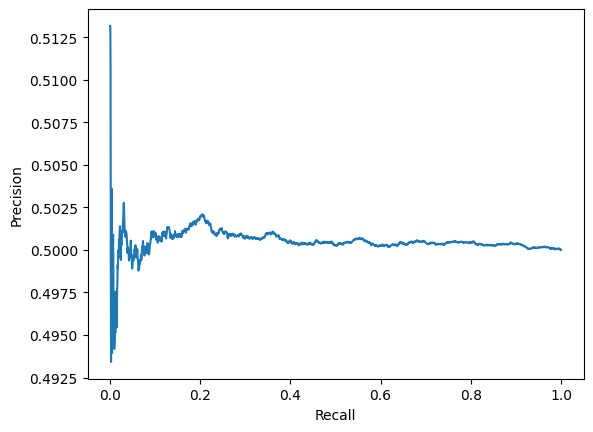

Model Accuracy 0.5002722280611049
FP rate [0.49817306033028297, 0.5012824835475027]
TR rate [0.4987175164524974, 0.5018269396697171]


In [ ]:
print(model.summary)
import matplotlib.pyplot as plt
pr = model.summary.pr.toPandas()
plt.plot(pr['recall'],pr['precision'])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()
print("Model Accuracy",model.summary.accuracy)
print("FP rate",model.summary.falsePositiveRateByLabel)
print("TR rate",model.summary.truePositiveRateByLabel)

In [ ]:
pr = predict_test.toPandas()
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0

print("Total",len(pr["Survived"]))
for lbl in range(len(pr["Survived"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TrueNegative+=1
    else:
      FalseNegative+=1
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Total 199756
TruePostive 50168 FalsePostive 50058
TrueNegative 49677 FalseNegative 49853


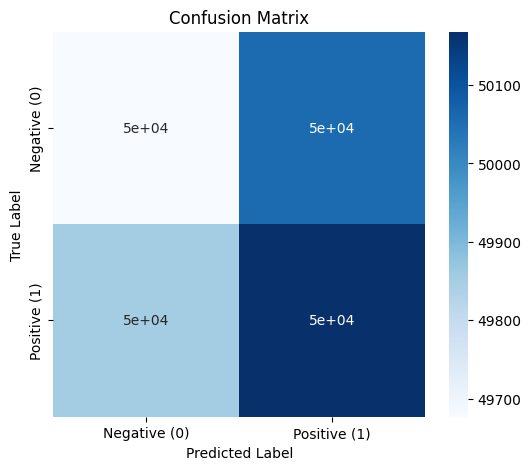

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive
conf_matrix = np.array([[TN, FP],
                        [FN, TP]])
labels = ["Negative (0)", "Positive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True,  cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")

Precision: 0.5005
Recall:    0.5016
F1-score:  0.5011
